In [1]:
import os
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs("artifacts/figures", exist_ok=True)

Using device: cuda


In [2]:
import os
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# 1. Seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 2. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 3. Structure
os.makedirs("artifacts/figures", exist_ok=True)

# 4. Transform и Dataset (CIFAR10 - более стабильная загрузка)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# 5. Split Train -> Train + Val
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Total train samples: {len(full_train_dataset)}")
print(f"Split -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# 6. DataLoaders
BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 7. Sanity Check
x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: x={x_batch.shape}, y={y_batch.shape}")
print(f"X range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

Using device: cuda
Total train samples: 50000
Split -> Train: 40000, Val: 10000, Test: 10000
Batch shape: x=torch.Size([64, 3, 32, 32]), y=torch.Size([64])
X range: [-1.000, 1.000]


In [3]:
class MLP(nn.Module):
    def __init__(self, input_size=3072, hidden_sizes=[256, 128, 64], num_classes=10):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            layers.append(nn.ReLU())
            prev_size = h_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

model = MLP().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x_batch.size(0)
        _, predicted = logits.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item() * x_batch.size(0)
            _, predicted = logits.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    
    return total_loss / total, 100. * correct / total

print("\n--- Test run (1 epoch) ---")
train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
val_loss, val_acc = evaluate(model, val_loader, criterion, device)
print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

MLP(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

--- Test run (1 epoch) ---
Train Loss: 1.6902, Acc: 39.63%
Val Loss: 1.5333, Acc: 45.74%



--- Running E1_Base ---
Epoch 1: Train Loss=1.6799, Val Acc=45.52%
Epoch 3: Train Loss=1.3568, Val Acc=49.82%
Epoch 6: Train Loss=1.1182, Val Acc=52.56%
Epoch 9: Train Loss=0.9317, Val Acc=52.59%
Epoch 12: Train Loss=0.7648, Val Acc=52.89%
Epoch 15: Train Loss=0.6265, Val Acc=52.46%

--- Running E2_Dropout ---
Epoch 1: Train Loss=1.8627, Val Acc=40.73%
Epoch 3: Train Loss=1.6336, Val Acc=47.47%
Epoch 6: Train Loss=1.5167, Val Acc=49.88%
Epoch 9: Train Loss=1.4383, Val Acc=50.51%
Epoch 12: Train Loss=1.3811, Val Acc=51.61%
Epoch 15: Train Loss=1.3413, Val Acc=51.98%

--- Running E3_BatchNorm ---
Epoch 1: Train Loss=1.6771, Val Acc=46.78%
Epoch 3: Train Loss=1.3460, Val Acc=51.78%
Epoch 6: Train Loss=1.1382, Val Acc=53.24%
Epoch 9: Train Loss=0.9801, Val Acc=54.69%
Epoch 12: Train Loss=0.8428, Val Acc=54.64%
Epoch 15: Train Loss=0.7285, Val Acc=54.20%

Choosing BatchNorm architecture for E4

--- Running E4_EarlyStop ---
Epoch 1: Train Loss=1.6727, Val Acc=46.71%
Epoch 3: Train Loss=1.34

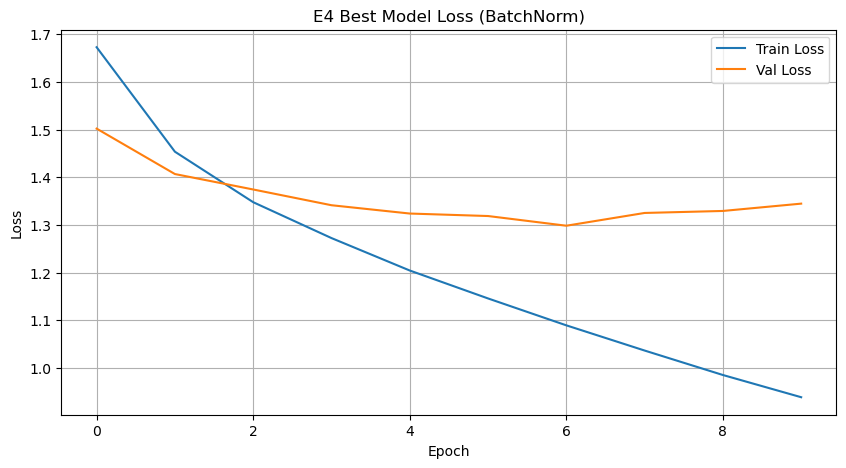


E1 Accuracy: 53.13%
E2 Accuracy: 52.08%
E3 Accuracy: 55.06%
E4 Accuracy: 54.48%


In [4]:
import copy

class MLP(nn.Module):
    def __init__(self, input_size=3072, hidden_sizes=[256, 128, 64], num_classes=10, use_dropout=False, dropout_p=0.3, use_bn=False):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(p=dropout_p))
            prev_size = h_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

def create_model(use_dropout=False, dropout_p=0.3, use_bn=False, input_size=3072):
    return MLP(input_size=input_size, use_dropout=use_dropout, dropout_p=dropout_p, use_bn=use_bn).to(device)

def run_experiment(name, model, epochs, early_stopping_patience=None):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    
    print(f"\n--- Running {name} ---")
    
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        if early_stopping_patience:
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
            
            if patience_counter >= early_stopping_patience:
                print(f"EarlyStopping at epoch {epoch+1}")
                break
        
        if not early_stopping_patience:
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                best_model_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 3 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f}, Val Acc={v_acc:.2f}%")
    
    if early_stopping_patience and best_model_state:
        model.load_state_dict(best_model_state)
        
    return history, best_val_acc, model

model_e1 = create_model(use_dropout=False, use_bn=False)
hist_e1, acc_e1, _ = run_experiment("E1_Base", model_e1, epochs=15)

model_e2 = create_model(use_dropout=True, dropout_p=0.3, use_bn=False)
hist_e2, acc_e2, _ = run_experiment("E2_Dropout", model_e2, epochs=15)

model_e3 = create_model(use_dropout=False, use_bn=True)
hist_e3, acc_e3, _ = run_experiment("E3_BatchNorm", model_e3, epochs=15)

if acc_e2 > acc_e3:
    print("\nChoosing Dropout architecture for E4")
    model_e4 = create_model(use_dropout=True, dropout_p=0.3, use_bn=False)
    arch_type = "Dropout"
else:
    print("\nChoosing BatchNorm architecture for E4")
    model_e4 = create_model(use_dropout=False, use_bn=True)
    arch_type = "BatchNorm"

hist_e4, acc_e4, model_e4_best = run_experiment("E4_EarlyStop", model_e4, epochs=50, early_stopping_patience=3)

torch.save(model_e4_best.state_dict(), "artifacts/best_model.pt")

plt.figure(figsize=(10, 5))
plt.plot(hist_e4['train_loss'], label='Train Loss')
plt.plot(hist_e4['val_loss'], label='Val Loss')
plt.title(f"E4 Best Model Loss ({arch_type})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/curves_best.png")
plt.show()

results_part_a = [
    {"experiment_id": "E1", "dataset": "CIFAR10", "seed": SEED, "model_summary": "Base MLP [256,128,64]", "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0, "epochs_trained": 15, "best_val_accuracy": acc_e1, "best_val_loss": hist_e1['val_loss'][-1]},
    {"experiment_id": "E2", "dataset": "CIFAR10", "seed": SEED, "model_summary": "MLP+Dropout(0.3) [256,128,64]", "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0, "epochs_trained": 15, "best_val_accuracy": acc_e2, "best_val_loss": hist_e2['val_loss'][-1]},
    {"experiment_id": "E3", "dataset": "CIFAR10", "seed": SEED, "model_summary": "MLP+BatchNorm [256,128,64]", "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0, "epochs_trained": 15, "best_val_accuracy": acc_e3, "best_val_loss": hist_e3['val_loss'][-1]},
    {"experiment_id": "E4", "dataset": "CIFAR10", "seed": SEED, "model_summary": f"MLP+{arch_type}+EarlyStop [256,128,64]", "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0, "epochs_trained": len(hist_e4['val_loss']), "best_val_accuracy": acc_e4, "best_val_loss": hist_e4['val_loss'][-1]}
]

print(f"\nE1 Accuracy: {acc_e1:.2f}%")
print(f"E2 Accuracy: {acc_e2:.2f}%")
print(f"E3 Accuracy: {acc_e3:.2f}%")
print(f"E4 Accuracy: {acc_e4:.2f}%")


--- Running O1_LR_High ---
Epoch 1: Train Loss=1.8699, Val Acc=42.60%
Epoch 3: Train Loss=1.6343, Val Acc=46.94%
Epoch 6: Train Loss=1.5166, Val Acc=49.12%

--- Running O2_LR_Low ---
Epoch 1: Train Loss=1.8637, Val Acc=41.89%
Epoch 3: Train Loss=1.6264, Val Acc=46.47%
Epoch 6: Train Loss=1.5149, Val Acc=48.41%

--- Running O3_SGD_Momentum_WD ---
Epoch 1: Train Loss=1.9549, Val Acc=39.84%
Epoch 3: Train Loss=1.6400, Val Acc=46.08%
Epoch 6: Train Loss=1.4961, Val Acc=50.09%
Epoch 9: Train Loss=1.4138, Val Acc=51.45%
Epoch 12: Train Loss=1.3562, Val Acc=51.65%
Epoch 15: Train Loss=1.3045, Val Acc=52.87%


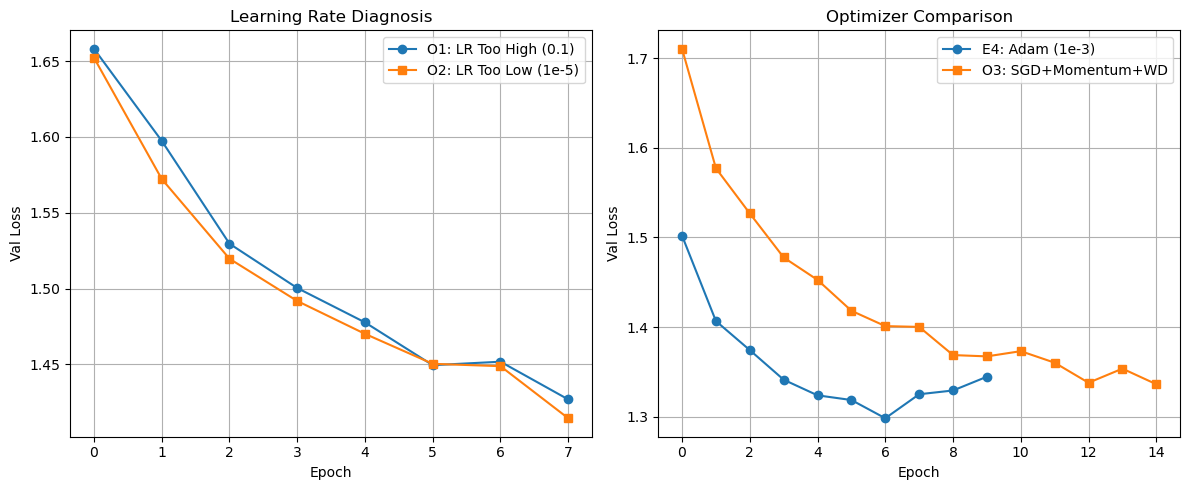


FINAL TEST ACCURACY: 54.14%

All artifacts saved:
- artifacts/best_model.pt
- artifacts/best_config.json
- artifacts/runs.csv
- artifacts/figures/curves_best.png
- artifacts/figures/curves_lr_extremes.png


In [5]:
model_o1 = create_model(use_dropout=True, dropout_p=0.3, use_bn=False)
hist_o1, acc_o1, _ = run_experiment("O1_LR_High", model_o1, epochs=8)

model_o2 = create_model(use_dropout=True, dropout_p=0.3, use_bn=False)
hist_o2, acc_o2, _ = run_experiment("O2_LR_Low", model_o2, epochs=8)

model_o3 = create_model(use_dropout=True, dropout_p=0.3, use_bn=False)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
criterion_o3 = nn.CrossEntropyLoss()

history_o3 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_o3 = 0.0

print(f"\n--- Running O3_SGD_Momentum_WD ---")
for epoch in range(15):
    t_loss, t_acc = train_one_epoch(model_o3, train_loader, optimizer_o3, criterion_o3, device)
    v_loss, v_acc = evaluate(model_o3, val_loader, criterion_o3, device)
    
    history_o3['train_loss'].append(t_loss)
    history_o3['val_loss'].append(v_loss)
    history_o3['train_acc'].append(t_acc)
    history_o3['val_acc'].append(v_acc)
    best_val_acc_o3 = max(best_val_acc_o3, v_acc)
    
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f}, Val Acc={v_acc:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_o1['val_loss'], label='O1: LR Too High (0.1)', marker='o')
plt.plot(hist_o2['val_loss'], label='O2: LR Too Low (1e-5)', marker='s')
plt.title("Learning Rate Diagnosis")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_e4['val_loss'], label='E4: Adam (1e-3)', marker='o')
plt.plot(history_o3['val_loss'], label='O3: SGD+Momentum+WD', marker='s')
plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()

results_all = results_part_a + [
    {"experiment_id": "O1", "dataset": "CIFAR10", "seed": SEED, "model_summary": "MLP+Dropout(0.3)", "optimizer": "Adam", "lr": 1e-1, "momentum": 0, "weight_decay": 0, "epochs_trained": 8, "best_val_accuracy": acc_o1, "best_val_loss": hist_o1['val_loss'][-1]},
    {"experiment_id": "O2", "dataset": "CIFAR10", "seed": SEED, "model_summary": "MLP+Dropout(0.3)", "optimizer": "Adam", "lr": 1e-5, "momentum": 0, "weight_decay": 0, "epochs_trained": 8, "best_val_accuracy": acc_o2, "best_val_loss": hist_o2['val_loss'][-1]},
    {"experiment_id": "O3", "dataset": "CIFAR10", "seed": SEED, "model_summary": "MLP+Dropout(0.3)", "optimizer": "SGD", "lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4, "epochs_trained": 15, "best_val_accuracy": best_val_acc_o3, "best_val_loss": history_o3['val_loss'][-1]}
]

with open("artifacts/runs.csv", "w", newline="") as f:
    fieldnames = ["experiment_id", "dataset", "seed", "model_summary", "optimizer", "lr", "momentum", "weight_decay", "epochs_trained", "best_val_accuracy", "best_val_loss"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results_all)

best_config = {
    "dataset": "CIFAR10",
    "seed": SEED,
    "model_architecture": arch_type,
    "input_size": 3072,
    "hidden_sizes": [256, 128, 64],
    "num_classes": 10,
    "optimizer": "Adam",
    "lr": 1e-3,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(hist_e4['val_loss']),
    "early_stopping_patience": 3,
    "best_val_accuracy": acc_e4
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

test_loss, test_acc = evaluate(model_e4_best, test_loader, criterion, device)
print(f"\n{'='*50}")
print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"{'='*50}")

print("\nAll artifacts saved:")
print("- artifacts/best_model.pt")
print("- artifacts/best_config.json")
print("- artifacts/runs.csv")
print("- artifacts/figures/curves_best.png")
print("- artifacts/figures/curves_lr_extremes.png")